In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
pd.to_numeric(df['TotalCharges'], errors='raise')

ValueError: Unable to parse string " " at position 488

In [7]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [9]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

it changes the empty single space ' ' to a actual null valu wich the pandas recognize

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

the actual convertion of the data type from str to numeric

In [11]:
df['TotalCharges'].dtype

dtype('float64')

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

we now that the empty values of totalcharges are belongs to new customers. so, filling with value 0

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['customerID'].duplicated().sum()

np.int64(0)

In [17]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

--- customerID ---
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

--- gender ---
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

--- Partner ---
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

--- Dependents ---
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

--- PhoneService ---
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

--- MultipleLines ---
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

--- InternetService ---
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

--- OnlineSecurity ---
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

--- OnlineBackup ---
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: st

C:\Users\Admin\AppData\Local\Temp\ipykernel_17832\1066548185.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [18]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [20]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [21]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

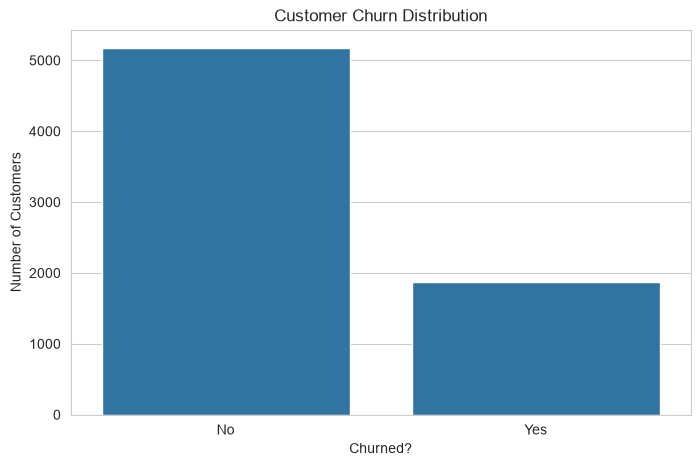

In [22]:
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churned?')
plt.ylabel('Number of Customers')
plt.show()

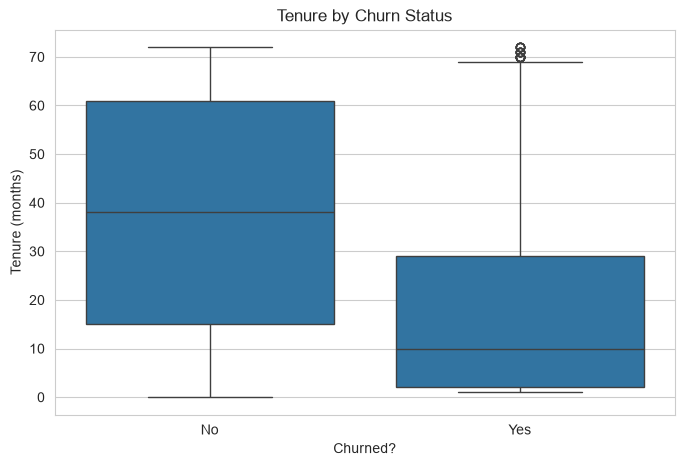

In [23]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure by Churn Status')
plt.xlabel('Churned?')
plt.ylabel('Tenure (months)')
plt.show()

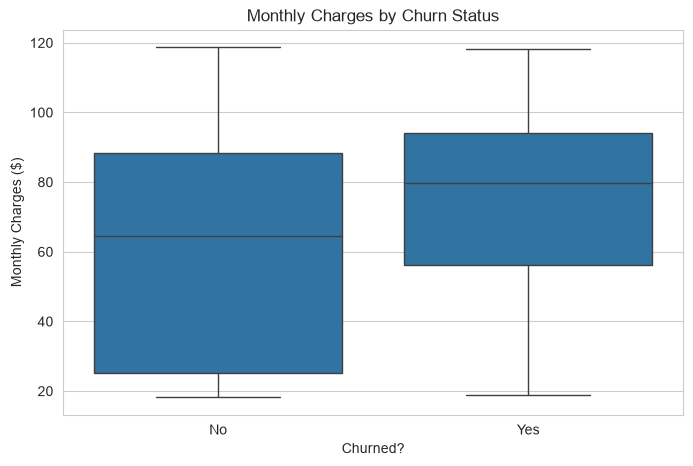

In [24]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churned?')
plt.ylabel('Monthly Charges ($)')
plt.show()

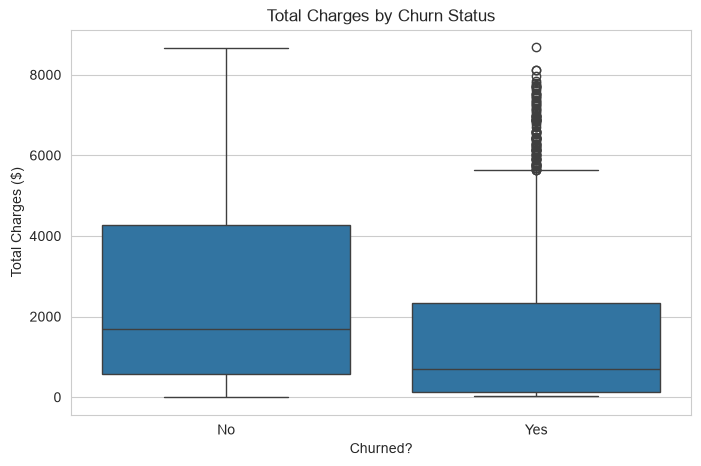

In [25]:
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title('Total Charges by Churn Status')
plt.xlabel('Churned?')
plt.ylabel('Total Charges ($)')
plt.show()

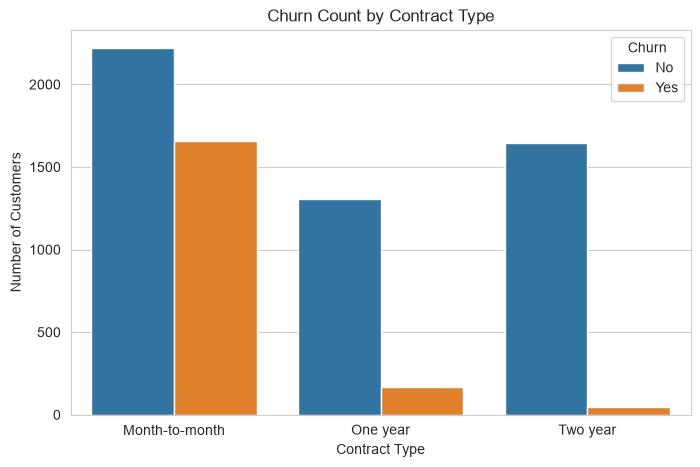

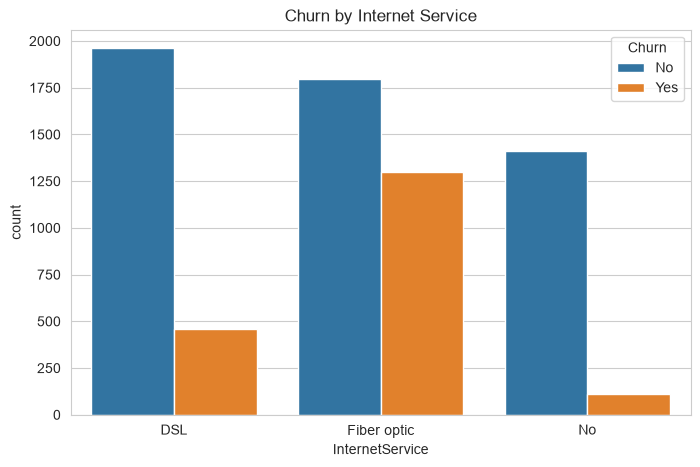

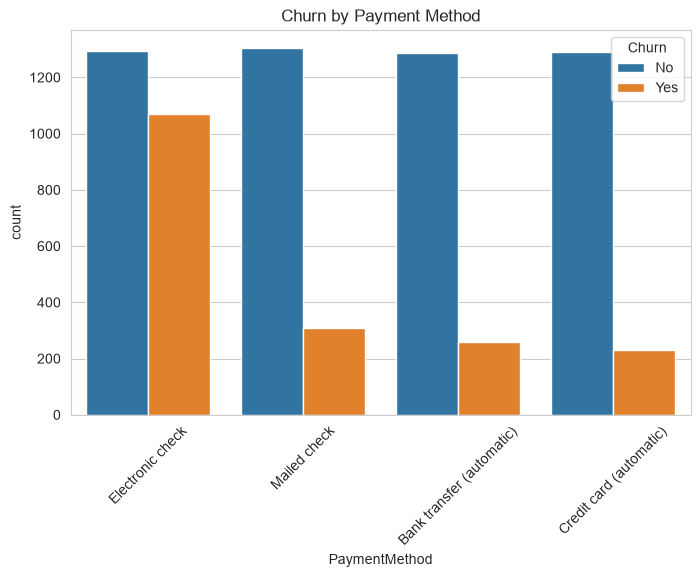

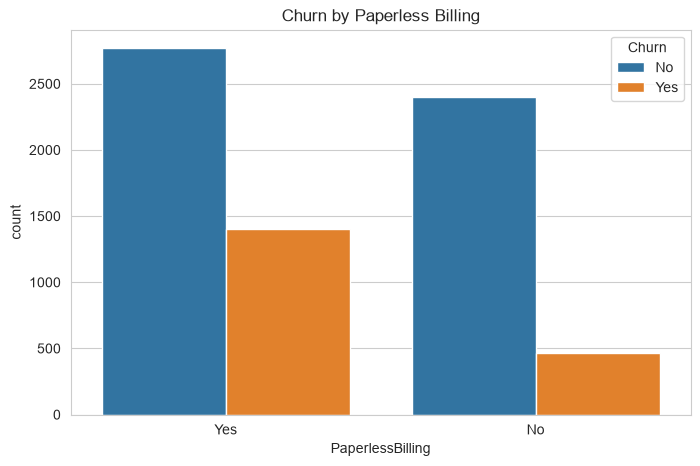

In [26]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn Count by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.show()

sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn by Payment Method')
plt.xticks(rotation=45)
plt.show()

sns.countplot(data=df, x='PaperlessBilling', hue='Churn')
plt.title('Churn by Paperless Billing')
plt.show()

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.826178
MonthlyCharges  0.247900        1.000000      0.651174
TotalCharges    0.826178        0.651174      1.000000


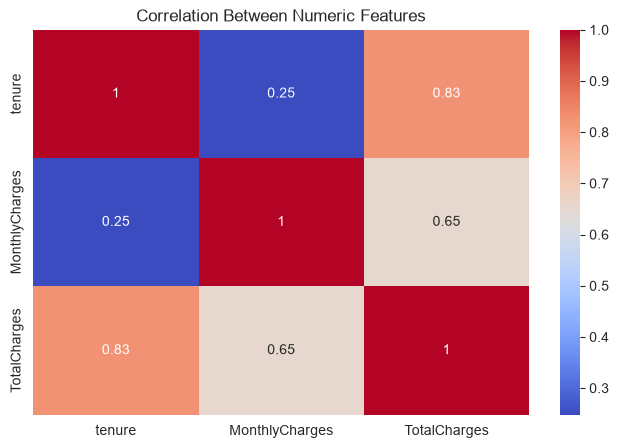

In [27]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Numeric Features')
plt.show()

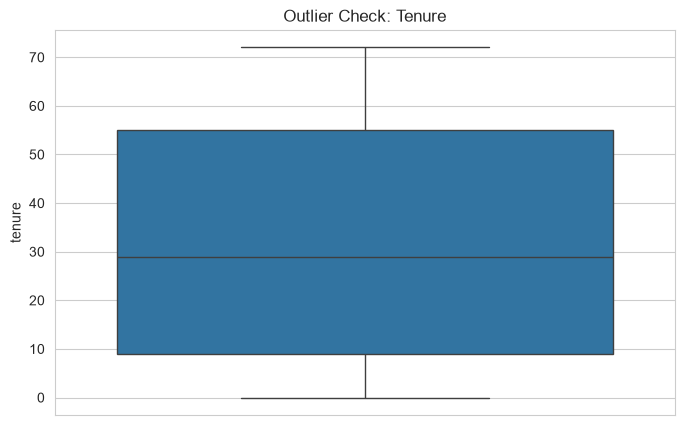

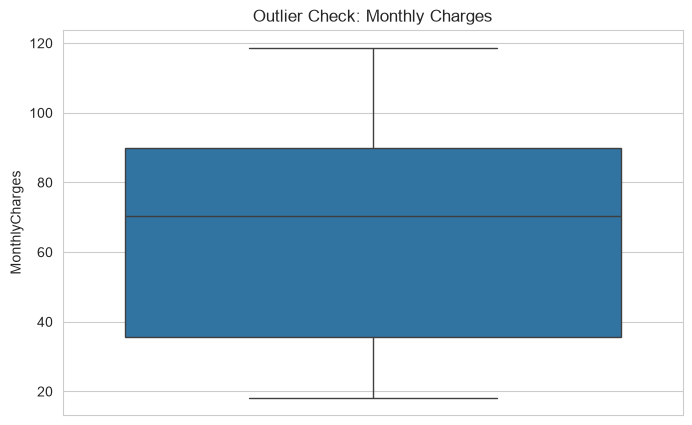

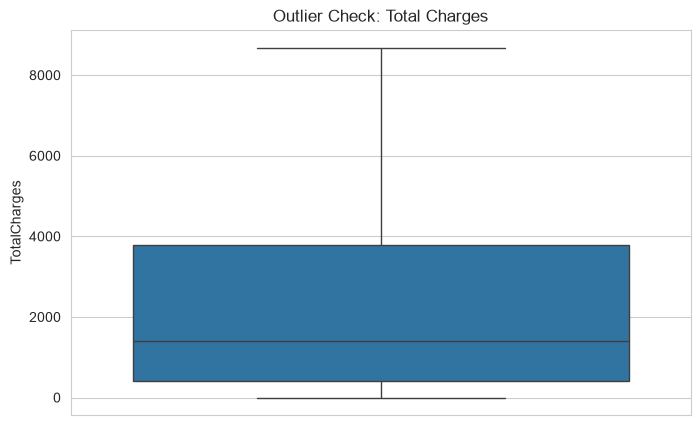

In [28]:
sns.boxplot(data=df, y='tenure')
plt.title('Outlier Check: Tenure')
plt.show()

sns.boxplot(data=df, y='MonthlyCharges')
plt.title('Outlier Check: Monthly Charges')
plt.show()

sns.boxplot(data=df, y='TotalCharges')
plt.title('Outlier Check: Total Charges')
plt.show()

In [29]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


In [30]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].median()


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.425,1679.525
Yes,10.0,79.650,703.550


In [31]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].std()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,24.113777,31.092648,2329.954215
Yes,19.531123,24.666053,1890.822994


In [32]:
def tenure_bucket(months):
    if months <= 12:
        return 'New'
    elif months <= 24:
        return 'Established'
    elif months <= 48:
        return 'Loyal'
    else:
        return 'Very Loyal'

df['tenure_group'] = df['tenure'].apply(tenure_bucket)
df[['tenure', 'tenure_group']].head(10)

,tenure,tenure_group
0,1,New
1,34,Loyal
2,2,New
3,45,Loyal
4,2,New
5,8,New
6,22,Established
7,10,New
8,28,Loyal
9,62,Very Loyal


Churn                No        Yes
tenure_group                      
Established   71.289062  28.710938
Loyal         79.611041  20.388959
New           52.561757  47.438243
Very Loyal    90.486824   9.513176


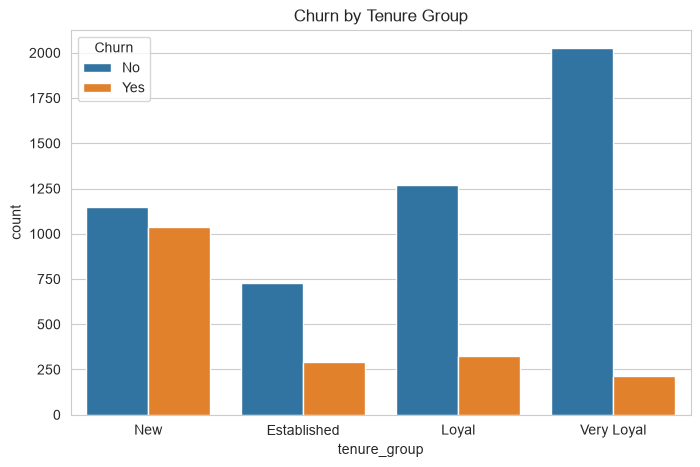

In [33]:
churn_by_group = df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack() * 100
print(churn_by_group)

sns.countplot(data=df, x='tenure_group', hue='Churn', order=['New', 'Established', 'Loyal', 'Very Loyal'])
plt.title('Churn by Tenure Group')
plt.show()

In [34]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    print(col, df[col].unique())

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PaperlessBilling <StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [35]:
df['Churn'].unique()

array([0, 1])

In [36]:
# Encode the 5 binary columns to 0/1
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
df['Partner'] = df['Partner'].map({'No': 0, 'Yes': 1})
df['Dependents'] = df['Dependents'].map({'No': 0, 'Yes': 1})
df['PhoneService'] = df['PhoneService'].map({'No': 0, 'Yes': 1})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'No': 0, 'Yes': 1})

# Check what text columns are still left
remaining_cat_cols = df.select_dtypes(include='object').columns
print(remaining_cat_cols)

# One-hot encode everything that's still text (except customerID, which we'll drop separately)
df_encoded = pd.get_dummies(df, columns=[col for col in remaining_cat_cols if col != 'customerID'], drop_first=True)

df_encoded.shape
df_encoded.head()

Index(['customerID', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaymentMethod', 'tenure_group'],
      dtype='str')


C:\Users\Admin\AppData\Local\Temp\ipykernel_17832\505913919.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_cat_cols = df.select_dtypes(include='object').columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_Loyal,tenure_group_New,tenure_group_Very Loyal
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,True,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,False,False,True,False,False,False,True,True,False,False
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,True,False,True,False
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,False,False,True,False,False,False,False,True,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,True,False,False,True,False


In [37]:
df_encoded.shape

(7043, 35)

In [38]:
# Drop customerID - it's not a useful feature
df_encoded = df_encoded.drop('customerID', axis=1)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

df_encoded[numeric_cols_to_scale] = scaler.fit_transform(df_encoded[numeric_cols_to_scale])

df_encoded[numeric_cols_to_scale].head()


,tenure,MonthlyCharges,TotalCharges
0,-1.277445,-1.160323,-0.992611
1,0.066327,-0.259629,-0.172165
2,-1.236724,-0.362660,-0.958066
3,0.514251,-0.746535,-0.193672
4,-1.236724,0.197365,-0.938874


In [39]:
df_encoded[numeric_cols_to_scale].describe()

,tenure,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.421273e-17,-6.406285e-17,-3.783239e-17
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-1.005780e+00
25%,-9.516817e-01,-9.725399e-01,-8.299464e-01
50%,-1.372744e-01,1.857327e-01,-3.905282e-01
75%,9.214551e-01,8.338335e-01,6.648034e-01
max,1.613701e+00,1.794352e+00,2.825806e+00


In [40]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Training churn rate:", y_train.mean())
print("Testing churn rate:", y_test.mean())

Training set size: (5634, 33)
Testing set size: (1409, 33)
Training churn rate: 0.2653532126375577
Testing churn rate: 0.2654364797728886


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Step 1: Create the model
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Step 2: Train it (this is where the "learning" happens)
log_model.fit(X_train, y_train)

# Step 3: Ask it to predict on data it has never seen
y_pred = log_model.predict(X_test)

# Step 4: Check how good the predictions were
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8005677785663591
Precision: 0.6576271186440678
Recall: 0.5187165775401069
F1 Score: 0.5799701046337817
Confusion Matrix:
 [[934 101]
 [180 194]]


In [46]:
from sklearn.tree import DecisionTreeClassifier

# Step 1: Create the model
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)

# Step 2: Train it
tree_model.fit(X_train, y_train)

# Step 3: Predict on test data
y_pred_tree = tree_model.predict(X_test)

# Step 4: Check performance
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

Accuracy: 0.794180269694819
Precision: 0.63125
Recall: 0.5401069518716578
F1 Score: 0.5821325648414986
Confusion Matrix:
 [[917 118]
 [172 202]]


In [47]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Create the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)

# Step 2: Train it
rf_model.fit(X_train, y_train)

# Step 3: Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Step 4: Check performance
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7885024840312278
Precision: 0.6666666666666666
Recall: 0.40641711229946526
F1 Score: 0.5049833887043189
Confusion Matrix:
 [[959  76]
 [222 152]]


In [48]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.800568   0.657627  0.518717  0.579970
1        Decision Tree  0.794180   0.631250  0.540107  0.582133
2        Random Forest  0.788502   0.666667  0.406417  0.504983


In [49]:
from sklearn.model_selection import cross_val_score

# Cross-validate all 3 models using F1 score (since it balances precision + recall)
log_cv = cross_val_score(LogisticRegression(max_iter=1000, random_state=42), X, y, cv=5, scoring='f1')
tree_cv = cross_val_score(DecisionTreeClassifier(random_state=42, max_depth=5), X, y, cv=5, scoring='f1')
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5), X, y, cv=5, scoring='f1')

print("Logistic Regression F1 scores:", log_cv, "Mean:", log_cv.mean())
print("Decision Tree F1 scores:", tree_cv, "Mean:", tree_cv.mean())
print("Random Forest F1 scores:", rf_cv, "Mean:", rf_cv.mean())

Logistic Regression F1 scores: [0.59467456 0.60237389 0.56547619 0.62109955 0.59192825] Mean: 0.5951104878570821
Decision Tree F1 scores: [0.56756757 0.4770017  0.47868852 0.52159468 0.53666147] Mean: 0.5163027893158569
Random Forest F1 scores: [0.5442623  0.53311793 0.49434572 0.54180602 0.52528548] Mean: 0.5277634894877484


In [50]:
from sklearn.model_selection import GridSearchCV

# Define which values of C to try
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Set up the search: try every value, using 5-fold cross-validation, scoring by F1
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

# Run the search
grid_search.fit(X_train, y_train)

# See the results
print("Best C value:", grid_search.best_params_)
print("Best F1 score during search:", grid_search.best_score_)

Best C value: {'C': 100}
Best F1 score during search: 0.5953106217223268


In [51]:
# Build the final model using the best C value found
final_model = LogisticRegression(C=100, max_iter=1000, random_state=42)
final_model.fit(X_train, y_train)

# Predict on the untouched test set
y_pred_final = final_model.predict(X_test)

# Final honest report card
print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Precision:", precision_score(y_test, y_pred_final))
print("Final Recall:", recall_score(y_test, y_pred_final))
print("Final F1 Score:", f1_score(y_test, y_pred_final))
print("Final Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))

Final Accuracy: 0.7963094393186657
Final Precision: 0.6407766990291263
Final Recall: 0.5294117647058824
Final F1 Score: 0.5797950219619327
Final Confusion Matrix:
 [[924 111]
 [176 198]]


ROC-AUC Score: 0.8411041359890464


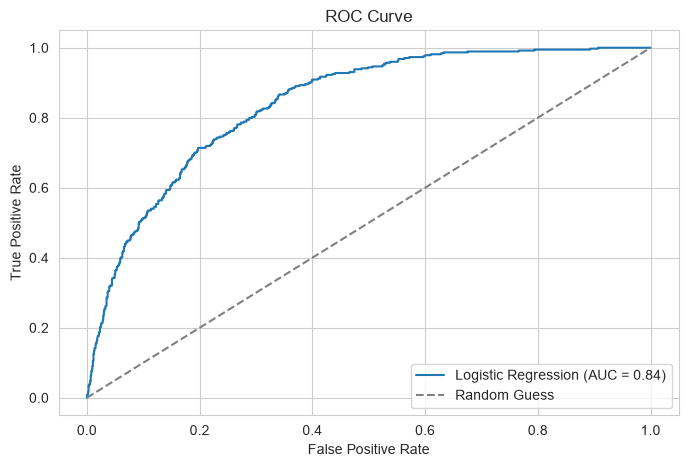

In [52]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get probability scores instead of just Yes/No predictions
y_proba = final_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
auc_score = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", auc_score)

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [53]:
import os

# Make sure a folder exists to hold Power BI's data source
os.makedirs('../data/powerbi', exist_ok=True)

# Export the cleaned df (before encoding/scaling) — this still has tenure_group and cleaned TotalCharges
df.to_csv('../data/powerbi/churn_cleaned_for_powerbi.csv', index=False)

print("Exported successfully. Shape:", df.shape)

Exported successfully. Shape: (7043, 22)


In [58]:
# Load a completely fresh copy of the raw data
df_powerbi = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Reapply only the safe cleaning steps (same logic as Steps 14 and 22)
df_powerbi['TotalCharges'] = df_powerbi['TotalCharges'].replace(' ', np.nan)
df_powerbi['TotalCharges'] = pd.to_numeric(df_powerbi['TotalCharges'])
df_powerbi['TotalCharges'] = df_powerbi['TotalCharges'].fillna(0)

df_powerbi['tenure_group'] = df_powerbi['tenure'].apply(tenure_bucket)

# Check it's still readable (not 0/1)
print(df_powerbi[['gender', 'Partner', 'Churn']].head())

# Export the corrected file
df_powerbi.to_csv('../data/powerbi/churn_cleaned_for_powerbi.csv', index=False)
print("Re-exported successfully. Shape:", df_powerbi.shape)

   gender Partner Churn
0  Female     Yes    No
1    Male      No    No
2    Male      No   Yes
3    Male      No    No
4  Female      No   Yes
Re-exported successfully. Shape: (7043, 22)
